# Linear model selection and regularization
In a regression the gaol is to find a model which relates the predictors X to the response Y by fitting model parameters $\beta$
e.g.

$$
Y = \beta_0 + \beta_1 X_1 + ... \beta_p X_p 
$$

Normally least squares is used to estimate or fit the parameters $\beta$. As long as the number of observations n is ways larger then the number of predictors p, n>>p least squares results in low variance and low bias but if n and p close to be the same size the variability rises and least squares tend to overfit on the train data. If in a more extreme case p>n least squares cant find a unique solution anymore. By **constraining** or **shrinking** the estimated coefficients the model variability can be decreased while increasing the bias in a neglectable way.

Furthermore the model interpretability can be increased if we find predictors which do not contribute to the response Y and thus can be seen as irrelevant and we can reduce the model complexity by either down weighting this predictors or even remove them to have a better situation for n vs. p.

Three methods will be investigated in this notebook:
1. Subset Selection: Select only a subset of the predictors p that relate to the response
2. Shrinkage: Fitting models with all p predictors but the estimated coefficients are shrunken towards 0 relative to the least squares estimates. This shrinkage also called regularization leads to lower variance if coefficients reach 0 shrinkage methods also can be used to perform subset selection.
3. Dimension Reduction: Projecting p predictors into an M-dimensional subspace where M < p by computing M linear combinations of p. Then model fitting is performed in the M space

# Subset selection

## Best subset selection
The idea of best subset selection is to find the best subset of predictors by fitting all possible models with a combination of the p predictors. This results in 2^p potential models which need to be tried or for each combination k of p predictors $\frac{p}{k}$ = p(p-1)/k potential models.

The algorithm works as follows:
1. Start with the $M_0$ model which hold only the intercept and is equal to the mean of the distribution
2. For k=1,2,...p
fit all models $\frac{p}{k}$ Mk and find the best with the lowest RSS or biggest R^2
3. Select a single best model from Mk using the prediction error on the validation set Cp BIC, AIC or another cross validation method

   Unnamed: 0   Income  Limit  Rating  Cards  Age  Education  Gender Student  \
0           1   14.891   3606     283      2   34         11    Male      No   
1           2  106.025   6645     483      3   82         15  Female     Yes   
2           3  104.593   7075     514      4   71         11    Male      No   
3           4  148.924   9504     681      3   36         11  Female      No   
4           5   55.882   4897     357      2   68         16    Male      No   

  Married  Ethnicity  Balance  
0     Yes  Caucasian      333  
1     Yes      Asian      903  
2      No      Asian      580  
3      No      Asian      964  
4     Yes  Caucasian      331  
Total iterations: 63
Test MSE for best subset models of different sizes: {1: np.float64(68340.88053675967), 2: np.float64(28914.52539641909), 3: np.float64(31221.62597218973), 4: np.float64(31065.4779706177), 5: np.float64(29878.076608331634), 6: np.float64(29863.873501581296)}


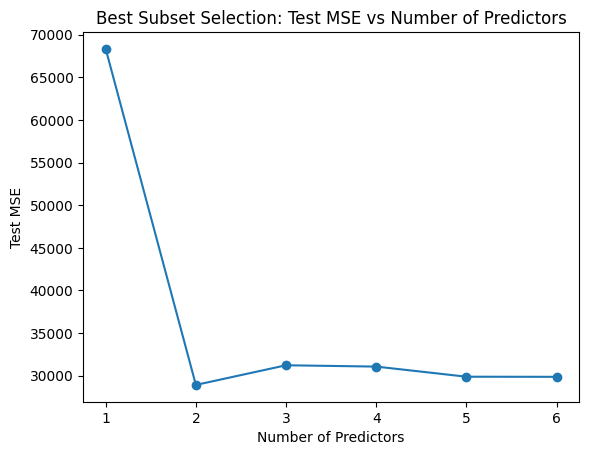

Best model uses 2 predictors: (0, 2) with Test MSE: 25725.575906919876
Coefficients of the best model: [-7.67212437  3.94926483]


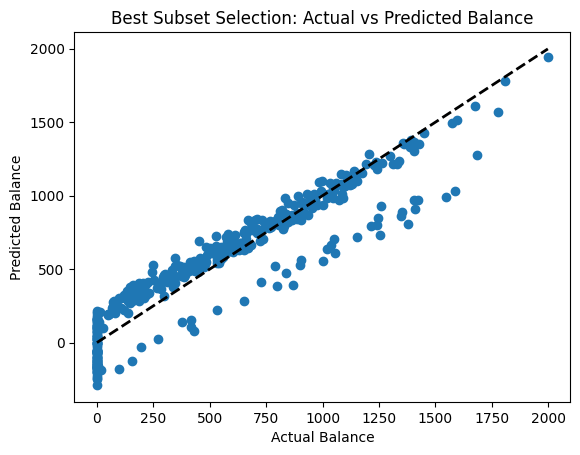

In [27]:
## Linear Model Selection using the best subset selection
#1. load the Credit dataset from the ISLR package.
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from itertools import combinations
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
# Load the Credit dataset
df = pd.read_csv("data/Credit.csv")
print(df.head())
# Prepare the feature matrix X and response vector y
X = df[["Income", "Limit", "Rating", "Cards", "Age", "Education"]]
y = df["Balance"]
# we have 6 predictors so we will have 2^6 = 64 possible models

# split the data into training and testing sets
    
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

def best_subset_selection(X, y):
    itterations = 0
    n, p = X.shape
    best_models = {}
    for k in range(1, p + 1):
        
        best_mse = float('inf')
        best_combination = None
        for combo in combinations(range(p), k):
            itterations += 1
            X_subset = X.iloc[:, list(combo)]
            model = LinearRegression().fit(X_subset, y)
            y_pred = model.predict(X_subset)
            mse = np.mean((y - y_pred) ** 2) # RSS / n
            if mse < best_mse:
                best_mse = mse
                best_combination = combo
        best_models[k] = (best_combination, best_mse)
    print("Total iterations:", itterations)
    return best_models

best_models = best_subset_selection(X_train, y_train)

# Evaluate the best models on the test set
test_mse = {}
for k, (combo, _) in best_models.items():
    X_subset_test = X_test.iloc[:, list(combo)]
    model = LinearRegression().fit(X_train.iloc[:, list(combo)], y_train)
    y_pred_test = model.predict(X_subset_test)
    mse_test = np.mean((y_test - y_pred_test) ** 2)
    test_mse[k] = mse_test
    
print("Test MSE for best subset models of different sizes:", test_mse)
# Plot test MSE against number of predictors

plt.plot(list(test_mse.keys()), list(test_mse.values()), marker='o')
plt.xlabel('Number of Predictors')
plt.ylabel('Test MSE')
plt.title('Best Subset Selection: Test MSE vs Number of Predictors')
plt.show()

# Print the best model with the lowest test MSE
best_k = min(test_mse, key=test_mse.get)
best_combo, best_mse = best_models[best_k]
print(f"Best model uses {best_k} predictors: {best_combo} with Test MSE: {best_mse}")

# fit the best model on the entire dataset and print the coefficients
final_model = LinearRegression().fit(X.iloc[:, list(best_combo)], y)
print("Coefficients of the best model:", final_model.coef_)

# Plot the fit of the best model
y_pred_final = final_model.predict(X.iloc[:, list(best_combo)])
plt.scatter(y, y_pred_final)
plt.xlabel('Actual Balance')
plt.ylabel('Predicted Balance')
plt.title('Best Subset Selection: Actual vs Predicted Balance')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.show()
    


# Stepwise selection
The main limitation of the best subset selection method is the computational cost as the number of models to investigate rises exponentially with the number of predictors. Therefore a step wise approaches which restrict the set of models are alternative approaches.

## Forward step stepwise selection
Forward stepwise selection starts with the minimum model Mo which contains no predictors and then step by step add one predictor. For each step all predictors are tested and the best one is keept fixed then the best second one will be added etc.

The algorithm works as follows:
1. Start with the null model Mo which predicts the mean
2. For k= 0 ... p
- choose all k-p models that add one predictor to Mk
- select the best predictor with the lowest RSS or highest R^2
3. from all Mk selected models select the single best model using cross validation e.g. minimizing the prediction error on the test set

Total iterations: 21
Test MSE for forward stepwise models of different sizes: {1: np.float64(68340.88053675967), 2: np.float64(28914.525396419085), 3: np.float64(29289.344884929335), 4: np.float64(30049.06915666418), 5: np.float64(29878.076608332405), 6: np.float64(29863.873501581977)}


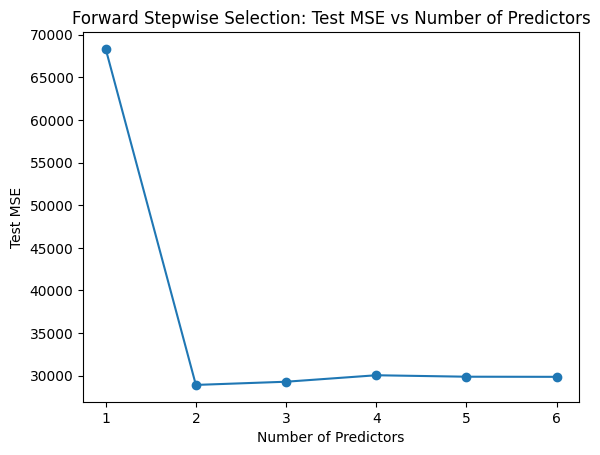

Best model uses 2 predictors: [2, 0] with Test MSE: 25725.575906919876
Coefficients of the best model: [ 3.94926483 -7.67212437]


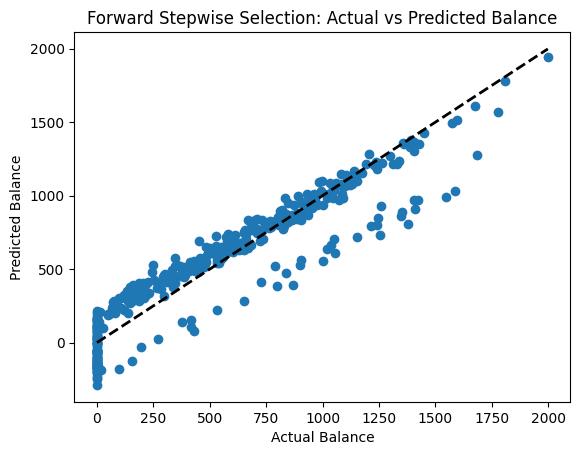

In [28]:
## Forward stepwise selection
# The idea of forward stepwise selection is to start with no predictors and add them one by
# one, at each step adding the predictor that improves the model the most until no further improvement is possible.

# Lets use again the credit dataset and implement forward stepwise selection to select the best model.
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from itertools import combinations
# load the Credit dataset
df = pd.read_csv("data/Credit.csv")
X = df[["Income", "Limit", "Rating", "Cards", "Age", "Education"]]
y = df["Balance"]

# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Forward stepwise selection function


def forward_stepwise_selection(X, y):
    n, p = X.shape
    itterations = 0
    selected_features = []
    remaining_features = list(range(p))
    best_models = {}
    
    for k in range(1, p + 1):
        best_mse = float('inf')
        best_feature = None
        
        for feature in remaining_features:
            itterations += 1
            current_features = selected_features + [feature]
            X_subset = X.iloc[:, current_features]
            model = LinearRegression().fit(X_subset, y)
            y_pred = model.predict(X_subset)
            mse = np.mean((y - y_pred) ** 2)
            
            if mse < best_mse:
                best_mse = mse
                best_feature = feature
                
        selected_features.append(best_feature)
        remaining_features.remove(best_feature)
        best_models[k] = (selected_features.copy(), best_mse)
    print("Total iterations:", itterations)
    return best_models

best_models = forward_stepwise_selection(X_train, y_train)
# Evaluate the best models on the test set
test_mse = {}
for k, (features, _) in best_models.items():
    X_subset_test = X_test.iloc[:, features]
    model = LinearRegression().fit(X_train.iloc[:, features], y_train)
    y_pred_test = model.predict(X_subset_test)
    mse_test = np.mean((y_test - y_pred_test) ** 2)
    test_mse[k] = mse_test
print("Test MSE for forward stepwise models of different sizes:", test_mse)
# Plot test MSE against number of predictors
plt.plot(list(test_mse.keys()), list(test_mse.values()), marker='o')
plt.xlabel('Number of Predictors')
plt.ylabel('Test MSE')
plt.title('Forward Stepwise Selection: Test MSE vs Number of Predictors')
plt.show()
# Print the best model with the lowest test MSE
best_k = min(test_mse, key=test_mse.get)
best_features, best_mse = best_models[best_k]
print(f"Best model uses {best_k} predictors: {best_features} with Test MSE: {best_mse}")
# fit the best model on the entire dataset and print the coefficients
final_model = LinearRegression().fit(X.iloc[:, best_features], y)
print("Coefficients of the best model:", final_model.coef_)
# Plot the fit of the best model
y_pred_final = final_model.predict(X.iloc[:, best_features])
plt.scatter(y, y_pred_final)
plt.xlabel('Actual Balance')
plt.ylabel('Predicted Balance')
plt.title('Forward Stepwise Selection: Actual vs Predicted Balance')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.show()

# Backward Stepwise selection
Backward stepwise selection works the same as forward stepwise selection but we start with a model M0 containing all predictors p and we step wise remove the predictor p which has the lowest impact meaning the lowest increase of the error. Like in forward selection we try all predictors per step k and keep the best subset of predictors p.



Total iterations: 20


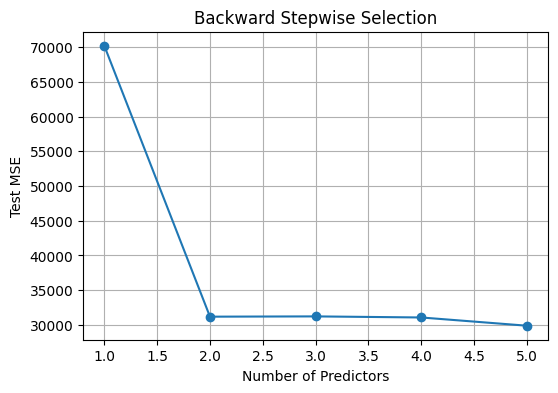

Best model uses 5 predictors:
Index(['Income', 'Limit', 'Rating', 'Cards', 'Age'], dtype='object')
Final model coefficients:
Income: -7.562
Limit: 0.129
Rating: 2.022
Cards: 11.553
Age: -0.888


In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Load data
df = pd.read_csv("data/Credit.csv")
X = df[["Income", "Limit", "Rating", "Cards", "Age", "Education"]]
y = df["Balance"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

def backward_stepwise_selection(X, y):
    n, p = X.shape
    selected_features = list(range(p))
    best_models = {}
    iterations = 0

    # Stop at 1 predictor (not 0!)
    for k in range(p, 1, -1):
        best_mse = np.inf
        feature_to_remove = None

        for feature in selected_features:
            iterations += 1
            candidate_features = selected_features.copy()
            candidate_features.remove(feature)

            X_subset = X.iloc[:, candidate_features]
            model = LinearRegression().fit(X_subset, y)
            y_pred = model.predict(X_subset)
            mse = np.mean((y - y_pred) ** 2)

            if mse < best_mse:
                best_mse = mse
                feature_to_remove = feature

        selected_features.remove(feature_to_remove)
        best_models[len(selected_features)] = (
            selected_features.copy(),
            best_mse
        )

    print("Total iterations:", iterations)
    return best_models

# Run backward stepwise selection
best_models = backward_stepwise_selection(X_train, y_train)

# Evaluate models on test set
test_mse = {}
for k, (features, _) in best_models.items():
    model = LinearRegression().fit(X_train.iloc[:, features], y_train)
    y_pred_test = model.predict(X_test.iloc[:, features])
    test_mse[k] = np.mean((y_test - y_pred_test) ** 2)

# Plot test MSE
plt.figure(figsize=(6,4))
plt.plot(list(test_mse.keys()), list(test_mse.values()), marker='o')
plt.xlabel("Number of Predictors")
plt.ylabel("Test MSE")
plt.title("Backward Stepwise Selection")
plt.grid(True)
plt.show()

# Best model
best_k = min(test_mse, key=test_mse.get)
best_features, _ = best_models[best_k]

print(f"Best model uses {best_k} predictors:")
print(X.columns[best_features])

# Fit final model
final_model = LinearRegression().fit(X.iloc[:, best_features], y)
print("Final model coefficients:")
for name, coef in zip(X.columns[best_features], final_model.coef_):
    print(f"{name}: {coef:.3f}")


# Best model selection

We described now several methods to select the best model based on subsets forward and backward search. So far we used the MSE on the testset as indication of model quality. This leads to interesting results. In the approaches best model selection and forward subset selection the best model was found using parameter 0,2 while in the backward selection we found 0,1,2,3,4,5 which is the full model. Therefor we should take a deeper look into metrics how to rate a models quality. 

The RSS or MSE=RSS/n will always decrease with more model parameters in the train set but not automatically in the test set. More concret the test error even can increase with a more flexible model in the test set. Therefor the reduction in model size needs to be taken into account in a metric as additional weighting of model complexity in the error metric. 

The four typical approaches are:
1. $C_p$ 
2. AIC (Akaike information criteria)
3. BIC (Bayes information criteria)
4. Adjusted $R^2$

$C_p$ is calculated using 

$$
C_p = 1/n (RSS + 2d \sigma^2)
$$
where d is the number of predictors p and $\sigma^2$ is the estimated error normally obtained from the full model with all predictors. Therefor more complex model with more flexibility get penalized by having d in the equation. $C_p$ is an unbiased estimator of the test MSE.

AIC is calulated similar to $C_p$ 

$$
AIC = 1/n (RSS + 2d \sigma^2)
$$

and for least squares regression is thus the same. 

BIC is derived from a bayesian viewpoint but for least square regression its quite similar to AIC and $C_p$

$$
BIC = 1/n (RSS + log(n)d \sigma^2)
$$

with n is the number of observations therefore BIC places heavier penalty on more complex models. 

Finally the addjusted $R^2$ is given by the 
$$
R^2 = 1- \frac{RSS}{TSS}
$$

where TSS is the total sum of squares for the response. 

The adjusted version is 

$$
Adjusted R^2 = 1- \frac{RSS/(n-d-1)}{TSS(n-1)}
$$

In contrast to AIC and BIC and $C_p$ the Adjusted $R^2$ is maximized for the best performing model.

Total iterations: 63
Estimated sigma: 160.22469571901843
Evaluating model with features: (2,)
Evaluating model with features: (0, 2)
Evaluating model with features: (0, 1, 2)
Evaluating model with features: (0, 1, 2, 4)
Evaluating model with features: (0, 1, 2, 3, 4)
Evaluating model with features: (0, 1, 2, 3, 4, 5)
Model with 1 predictors: AIC=53588.606, BIC=53590.205, Adjusted R²=0.745
Model with 2 predictors: AIC=26332.955, BIC=26336.153, Adjusted R²=0.874
Model with 3 predictors: AIC=26097.394, BIC=26102.191, Adjusted R²=0.875
Model with 4 predictors: AIC=25888.342, BIC=25894.738, Adjusted R²=0.876
Model with 5 predictors: AIC=25714.551, BIC=25722.546, Adjusted R²=0.877
Model with 6 predictors: AIC=25676.760, BIC=25686.353, Adjusted R²=0.876


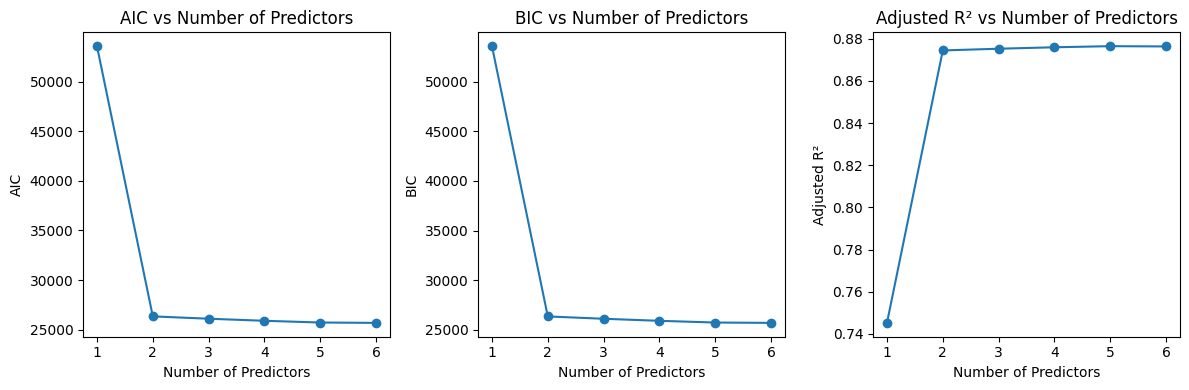

In [30]:
## Calculate AIC, BIC and adj-R² for model selection
# Function to calculate AIC, BIC, and adjusted R²

def AIC(model, X, y, sigma):
    n = len(y)
    d = X.shape[1]
    residuals = y - model.predict(X)
    rss = np.sum(residuals ** 2)
    aic = 1/n * (rss + 2 * d * sigma) # 6.2
    return aic

def BIC(model, X, y, sigma):
    n = len(y)
    d = X.shape[1]
    residuals = y - model.predict(X)
    rss = np.sum(residuals ** 2)
    bic = 1/n * (rss + np.log(n) * d * sigma) # 6.3
    return bic

def adjusted_R2(model, X, y):
    n = len(y)
    d = X.shape[1]
    TSS = np.sum((y - np.mean(y)) ** 2)
    RSS = np.sum((y - model.predict(X)) ** 2)
    r2 = 1 - RSS / TSS
    adj_r2 = 1  - (RSS/(n - d - 1)) / (TSS/(n - 1)) # 6.4
    return adj_r2

# Example usage with the Credit dataset
df = pd.read_csv("data/Credit.csv")
X = df[["Income", "Limit", "Rating", "Cards", "Age", "Education"]]
y = df["Balance"]
# make a full model search using best subset selection
best_models = best_subset_selection(X, y) # from previous code

# estimate sigma^2 using the full model
full_model = LinearRegression().fit(X, y)
y_pred_full = full_model.predict(X)
sigma2 = np.mean((y - y_pred_full) ** 2)
sigma = np.sqrt(sigma2)
print("Estimated sigma:", sigma)
# Calculate AIC, BIC, and adjusted R² for each model
model_selection_metrics = {}

 
for k, (features, _) in best_models.items():
    print("Evaluating model with features:", features)
    X_subset = X.iloc[:, list(features)]
    model = LinearRegression().fit(X_subset, y)
    aic = AIC(model, X_subset, y, sigma)
    bic = BIC(model, X_subset, y, sigma)
    adj_r2 = adjusted_R2(model, X_subset, y)
    model_selection_metrics[k] = {
        "AIC": aic,
        "BIC": bic,
        "Adjusted R²": adj_r2
    }
# Print the metrics
for k, metrics in model_selection_metrics.items():
    print(f"Model with {k} predictors: AIC={metrics['AIC']:.3f}, BIC={metrics['BIC']:.3f}, Adjusted R²={metrics['Adjusted R²']:.3f}")
## Plot the metrics vs number of predictors
aic_values = [metrics["AIC"] for metrics in model_selection_metrics.values()]
bic_values = [metrics["BIC"] for metrics in model_selection_metrics.values()]
adj_r2_values = [metrics["Adjusted R²"] for metrics in model_selection_metrics.values()]
num_predictors = list(model_selection_metrics.keys())
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(num_predictors, aic_values, marker='o')
plt.xlabel('Number of Predictors')
plt.ylabel('AIC')
plt.title('AIC vs Number of Predictors')
plt.subplot(1, 3, 2)
plt.plot(num_predictors, bic_values, marker='o')
plt.xlabel('Number of Predictors')
plt.ylabel('BIC')
plt.title('BIC vs Number of Predictors')
plt.subplot(1, 3, 3)
plt.plot(num_predictors, adj_r2_values, marker='o')
plt.xlabel('Number of Predictors')
plt.ylabel('Adjusted R²')
plt.title('Adjusted R² vs Number of Predictors')
plt.tight_layout()
plt.show()

## Cross Validation 

Alterantiv to AIC, BIC etc. is the use of crossvalidation (K fold LOOCV ...). This is computational more demanding but gives better intuition on how a model is performing on unseen test data. In this case the Mk models are evaluated on the cross validation set or k times on the k fold cross validation set and the test MSE is then averaged.



## Shrinkage Methods

In **ordinary least squares (OLS)**, the regression coefficients are chosen to minimize the **residual sum of squares (RSS)**:
$$
\text{RSS}(\boldsymbol{\beta})
=
\sum_{i=1}^n
\left(y_i - \beta_0 - \sum_{j=1}^p \beta_j x_{ij}\right)^2.
$$

While OLS is unbiased, it can have **high variance**, particularly when:
- $p$ is large relative to $n$,
- predictors are highly correlated,
- or the signal-to-noise ratio is low.

A small increase in bias can lead to a large reduction in variance, thereby improving test MSE. Shrinkage methods achieve this by **penalizing large coefficient values**, forcing the model
toward simpler, more stable solutions.

## Ridge Regression 

### Penalized formulation

Ridge regression minimizes the following objective:
$$
\min_{\boldsymbol{\beta}}
\left\{
\sum_{i=1}^n
\left(y_i - \beta_0 - \sum_{j=1}^p \beta_j x_{ij}\right)^2
\;+\;
\lambda \sum_{j=1}^p \beta_j^2
\right\}.
$$

- $\lambda \ge 0$ is the **tuning parameter** controlling the amount of shrinkage.
- The intercept $\beta_0$ is **not penalized**.

### Constrained formulation 

The penalized problem is equivalent to:
$$
\min_{\boldsymbol{\beta}} \; \text{RSS}(\boldsymbol{\beta})
\quad \text{subject to} \quad
\sum_{j=1}^p \beta_j^2 \le s,
$$
for some $s \ge 0$.

### Geometric interpretation

- The RSS contours are **ellipses** in $(\beta_1, \beta_2)$ space.
- The constraint $\sum_j \beta_j^2 \le s$ defines a **circle** (or a sphere in higher dimensions).
- The ridge solution occurs where the smallest RSS ellipse first touches the circle.

Because the $L_2$ constraint has a smooth boundary:
- coefficients are continuously shrunk toward zero,
- but **never exactly equal to zero**.

### Key properties 

- Reduces variance of coefficient estimates
- Particularly effective when predictors are highly correlated
- All predictors remain in the model
- Improves prediction accuracy at the cost of some bias

---

## Lasso Regression 

### Penalized formulation

The lasso minimizes:
$$
\min_{\boldsymbol{\beta}}
\left\{
\sum_{i=1}^n
\left(y_i - \beta_0 - \sum_{j=1}^p \beta_j x_{ij}\right)^2
\;+\;
\lambda \sum_{j=1}^p |\beta_j|
\right\}.
$$

### Constrained formulation 

Equivalently:
$$
\min_{\boldsymbol{\beta}} \; \text{RSS}(\boldsymbol{\beta})
\quad \text{subject to} \quad
\sum_{j=1}^p |\beta_j| \le s.
$$

### Geometric interpretation

- RSS contours are ellipses.
- The $L_1$ constraint defines a **diamond-shaped region**.
- The corners of the diamond lie on the coordinate axes.

As shown in ISL Figure 6.7:
- the RSS ellipse often touches the constraint at a corner,
- leading to **exactly zero coefficients**.

### Key properties 

- Produces **sparse solutions**
- Performs automatic variable selection
- Easier to interpret than ridge regression
- Can be unstable when predictors are strongly correlated

---

## Comparison of Ridge and Lasso 

| Aspect | Ridge Regression | Lasso Regression |
|------|------------------|------------------|
| Penalty | $L_2$: $\sum \beta_j^2$ | $L_1$: $\sum |\beta_j|$ |
| ISL Equation | Eq. 6.6 | Eq. 6.7 |
| Constraint shape | Circle | Diamond |
| Sparsity | No | Yes |
| Multicollinearity | Very robust | May select one of many correlated predictors |
| Bias–variance trade-off | Low variance, higher bias | Higher bias, sparse solution |
| Interpretability | Moderate | High |

### Final takeaway 

> Ridge regression is preferred when many predictors contribute to the response,
> whereas lasso is preferred when only a small subset of predictors is truly relevant.
> Both methods improve prediction accuracy by shrinking coefficients, thereby controlling variance.



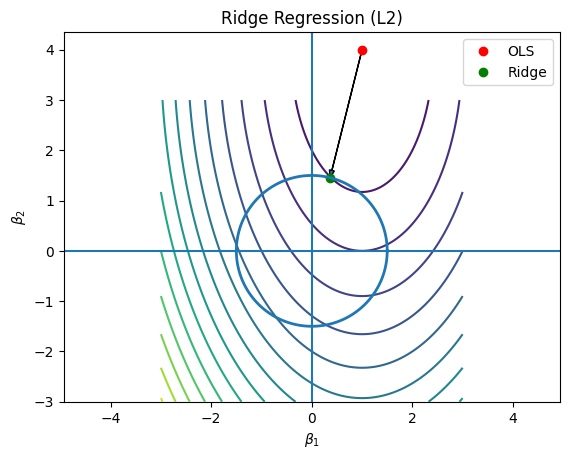

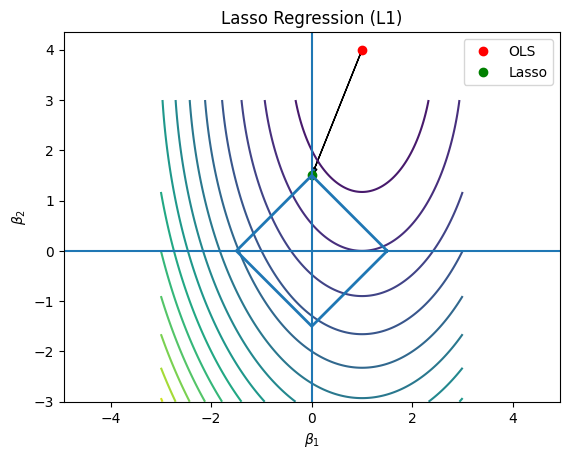

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# Grid
# -------------------------------------------------
beta1 = np.linspace(-3, 3, 400)
beta2 = np.linspace(-3, 3, 400)
B1, B2 = np.meshgrid(beta1, beta2)

# -------------------------------------------------
# RSS surface (ellipses)
# -------------------------------------------------
RSS = (B1 - 1)**2 + (0.5 * B2 - 2)**2

# True OLS minimum
min_rss = (1, 4)

# Regularization parameter
c = 1.5

# -------------------------------------------------
# Ridge intersection (radial projection)
# -------------------------------------------------
norm = np.sqrt(min_rss[0]**2 + min_rss[1]**2)
intersect_L2 = (c * min_rss[0] / norm,
                c * min_rss[1] / norm)

# -------------------------------------------------
# Lasso intersection (corner of diamond)
# -------------------------------------------------
intersect_L1 = (0, c)   # sparsity: beta1 = 0

# -------------------------------------------------
# Ridge plot
# -------------------------------------------------
plt.figure()
plt.contour(B1, B2, RSS, levels=16)
plt.plot(*min_rss, 'ro', label='OLS')
plt.plot(*intersect_L2, 'go', label='Ridge')

# shrinkage arrow
plt.arrow(min_rss[0], min_rss[1],
          intersect_L2[0]-min_rss[0],
          intersect_L2[1]-min_rss[1],
          head_width=0.1, length_includes_head=True)

theta = np.linspace(0, 2*np.pi, 400)
plt.plot(c*np.cos(theta), c*np.sin(theta), lw=2)

plt.axhline(0); plt.axvline(0)
plt.xlabel(r"$\beta_1$")
plt.ylabel(r"$\beta_2$")
plt.title("Ridge Regression (L2)")
plt.axis("equal")
plt.legend()
plt.show()

# -------------------------------------------------
# Lasso plot
# -------------------------------------------------
plt.figure()
plt.contour(B1, B2, RSS, levels=16)
plt.plot(*min_rss, 'ro', label='OLS')
plt.plot(*intersect_L1, 'go', label='Lasso')

# shrinkage + selection arrow
plt.arrow(min_rss[0], min_rss[1],
          intersect_L1[0]-min_rss[0],
          intersect_L1[1]-min_rss[1],
          head_width=0.1, length_includes_head=True)

plt.plot([ c,  0, -c,  0,  c],
         [ 0,  c,  0, -c,  0], lw=2)

plt.axhline(0); plt.axvline(0)
plt.xlabel(r"$\beta_1$")
plt.ylabel(r"$\beta_2$")
plt.title("Lasso Regression (L1)")
plt.axis("equal")
plt.legend()
plt.show()


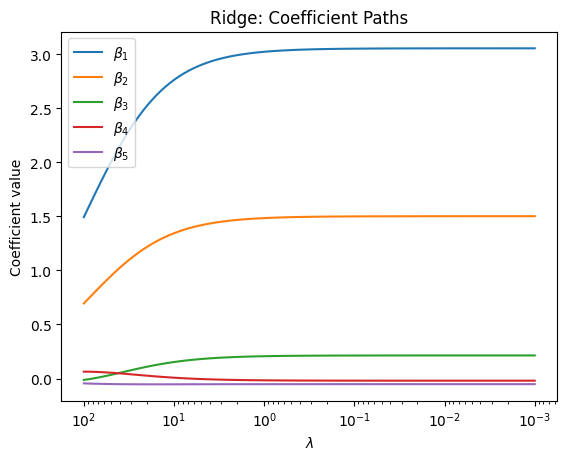

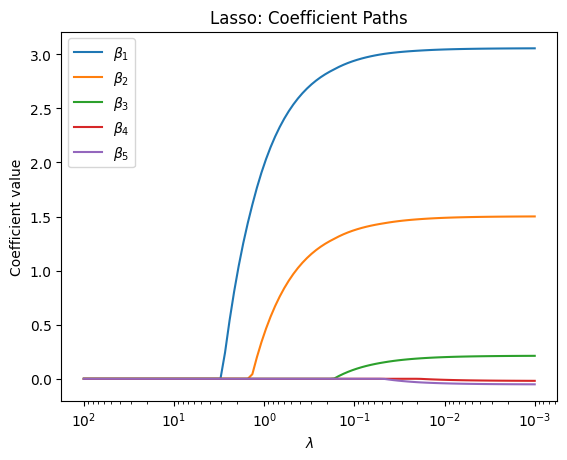

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso

np.random.seed(0)

n, p = 100, 5
X = np.random.randn(n, p)

true_beta = np.array([3, 1.5, 0, 0, 0])
y = X @ true_beta + np.random.randn(n)

# standardize predictors
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

# center response
y = y - y.mean()

lambdas = np.logspace(2, -3, 100)


ridge_coefs = []

for lam in lambdas:
    model = Ridge(alpha=lam, fit_intercept=False)
    model.fit(X_std, y)
    ridge_coefs.append(model.coef_)

ridge_coefs = np.array(ridge_coefs)

plt.figure()
for j in range(p):
    plt.plot(lambdas, ridge_coefs[:, j], label=f"$\\beta_{j+1}$")

plt.xscale("log")
plt.gca().invert_xaxis()
plt.xlabel(r"$\lambda$")
plt.ylabel("Coefficient value")
plt.title("Ridge: Coefficient Paths")
plt.legend()
plt.show()


lasso_coefs = []

for lam in lambdas:
    model = Lasso(alpha=lam, fit_intercept=False, max_iter=10000)
    model.fit(X_std, y)
    lasso_coefs.append(model.coef_)

lasso_coefs = np.array(lasso_coefs)

plt.figure()
for j in range(p):
    plt.plot(lambdas, lasso_coefs[:, j], label=f"$\\beta_{j+1}$")

plt.xscale("log")
plt.gca().invert_xaxis()
plt.xlabel(r"$\lambda$")
plt.ylabel("Coefficient value")
plt.title("Lasso: Coefficient Paths")
plt.legend()
plt.show()


Ridge regression shrinks parameters stronger with higher regularization while lasso regression shrink components to 0 with increasing regularization strength. The correct selection of $\lambda$ is done using a cross validation set.

# Dimension Reduction Methods
The previous ideas operated on the original data space X and try to minimize the impact of predictors with low amount of information about Y. 

The idea in dimension reduction is to reduce the number of predictors X which are used to derive the estimate of the response Y. This is done by transforming X into a different space with M < p predictors.  Afterwards parameters $\beta$ are estimated in this space on the reduced set of predictors which are a linear combination of them.


# Principal Component Regression (PCR)

Principal Component Regression (PCR) is a two-step approach for linear regression with high-dimensional or highly correlated predictors:

1. Apply Principal Component Analysis (PCA) to the predictor matrix $X$
2. Regress the response variable $Y$ on the first $M < p$ principal components where M is the number of principal components used in the regression

As in *Introduction to Statistical Learning* (ISL), Section 6.3, the PCA step is performed **using only $X$**, without any reference to the response $Y$.

## Motivation for Dimension Reduction

In the classical linear regression model

$$
Y = \beta_0 + \sum_{j=1}^p \beta_j X_j + \varepsilon,
$$

several issues arise when $p$ is large or when the predictors are highly correlated:

- high variance of the OLS estimates  
- numerical instability  
- poor predictive performance  

PCR addresses these issues by:
- transforming the predictors into an orthogonal basis  
- performing regression in a lower-dimensional subspace  

## Principal Component Analysis (PCA)

### Standardization of the Predictors

Before applying PCA, the predictors are centered and scaled:

$$
\tilde X_{ij} = \frac{X_{ij} - \bar X_j}{s_j},
$$

where $\bar X_j$ and $s_j$ denote the sample mean and standard deviation of predictor $j$. PCA is driven by variance. Without scaling, predictors with larger scales would dominate the principal components.

In the following, $X$ denotes the standardized predictor matrix.

### Covariance Matrix of $X$

The empirical covariance matrix of $X$ is

$$
\Sigma = \frac{1}{n-1} X^\top X.
$$

Properties:
- $\Sigma$ is symmetric  
- $\Sigma$ is positive semidefinite  
- $\Sigma \in \mathbb{R}^{p \times p}$  

---

### Eigenvalue Decomposition

PCA is based on the eigenvalue decomposition of $\Sigma$:

$$
\Sigma = V \Lambda V^\top,
$$

where:
- $V = (v_1, \dots, v_p)$ contains orthonormal eigenvectors  
- $\Lambda = \mathrm{diag}(\lambda_1, \dots, \lambda_p)$ with
  $$
  \lambda_1 \ge \lambda_2 \ge \dots \ge \lambda_p \ge 0
  $$

**Interpretation:**
- $v_m$: direction of the $m$-th principal component  
- $\lambda_m$: variance explained by the $m$-th component  

---

### Definition of the Principal Components

The $m$-th principal component is defined as

$$
Z_m = X v_m,
$$

or component-wise,

$$
Z_{im} = \sum_{j=1}^p v_{jm} X_{ij}.
$$

Properties:
- the $Z_m$ are mutually orthogonal  
- $\mathrm{Var}(Z_m) = \lambda_m$  
- $Z_1$ captures the maximum possible variance in $X$  

---

### PCA via Singular Value Decomposition (SVD)

In practice, PCA is computed using the singular value decomposition of $X$:

$$
X = U D V^\top.
$$

Connections to PCA:
- columns of $V$ are the principal component directions  
- the eigenvalues satisfy
$$
\lambda_m = \frac{d_m^2}{n-1}
$$
- the matrix of principal components is
$$
Z = X V = U D
$$

This formulation is exactly the one used in ISL, Section 6.3.

---

## Principal Component Regression

### Selecting the First $M$ Components

Only the first $M < p$ principal components are retained:

$$
Z^{(M)} = (Z_1, \dots, Z_M).
$$

The choice of $M$ is typically based on:
- cross-validation  
- scree plots  
- cumulative proportion of variance explained  


### Regressing $Y$ on the Principal Components

The PCR model is

$$
Y = \beta_0 + \sum_{m=1}^M \theta_m Z_m + \varepsilon.
$$

Because the $Z_m$ are orthogonal:
- there is no multicollinearity  
- ordinary least squares estimation is numerically stable  


### Transformation Back to the Original Predictor Space

The regression coefficients in the original predictor space are

$$
\hat\beta = \sum_{m=1}^M \theta_m v_m.
$$

In matrix form (ISL, Equation 6.15):

$$
\hat\beta = V_M \hat\theta,
$$

where $V_M = (v_1, \dots, v_M)$.

## Summary, Interpretation and Limitations
- PCA reduces the dimensionality of $X$ via orthogonal projection  
- PCR applies OLS regression to the first $M$ principal components 
- PCR selects directions that explain the most variance in $X$
- these directions are not necessarily the most predictive for $Y$
- PCR may perform worse than:
  - Ridge Regression  
  - Partial Least Squares (PLS)   

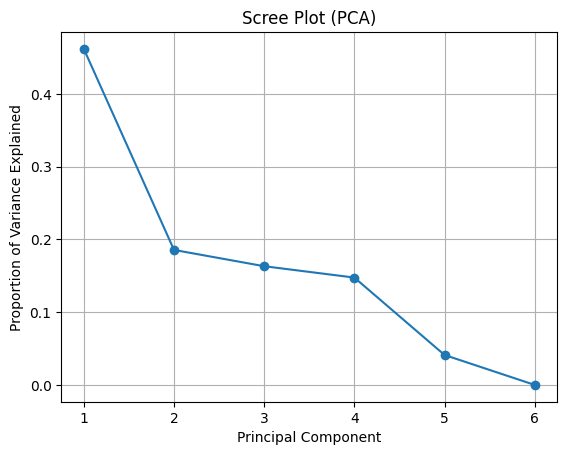

Test MSE comparison
PCR (2 PCs):   114963.03
PCR (all PCs): 29863.87
Ridge:         29817.99


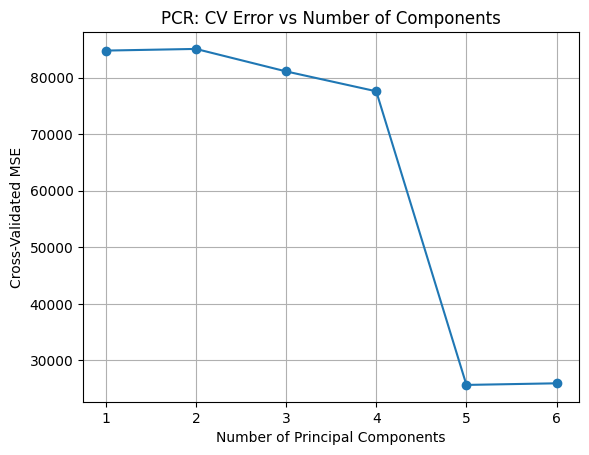


PCR coefficients in original predictor space:
Income       -7.304598
Limit         0.130796
Rating        1.934024
Cards        14.201519
Age          -0.914146
Education     2.286590
dtype: float64
Intercept: -475.01086297645713


In [33]:
# ============================================================
# PCR, Ridge, CV, and Back-Transformation on the Credit Dataset
# Drop-in replacement for the original code cell
# ISL Section 6.3 compliant
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split, KFold, GridSearchCV

# ------------------------------------------------------------
# Load data
# ------------------------------------------------------------
df = pd.read_csv("data/Credit.csv")

X = df[["Income", "Limit", "Rating", "Cards", "Age", "Education"]]
y = df["Balance"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ------------------------------------------------------------
# Standardization (training data statistics only)
# ------------------------------------------------------------
X_mean = X_train.mean()
X_std = X_train.std(ddof=0)

X_train_std = (X_train - X_mean) / X_std
X_test_std  = (X_test  - X_mean) / X_std

# ------------------------------------------------------------
# PCA from scratch (ISL)
# ------------------------------------------------------------
# Covariance matrix
Sigma = np.cov(X_train_std, rowvar=False)

# Eigenvalue decomposition (Sigma is symmetric)
eigenvalues, eigenvectors = np.linalg.eigh(Sigma)

# Sort by decreasing eigenvalues
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# Principal components
X_train_pca = X_train_std.values @ eigenvectors
X_test_pca  = X_test_std.values  @ eigenvectors

# ------------------------------------------------------------
# Scree plot (explained variance)
# ------------------------------------------------------------
explained_variance_ratio = eigenvalues / eigenvalues.sum()

plt.figure()
plt.plot(
    range(1, len(explained_variance_ratio) + 1),
    explained_variance_ratio,
    marker="o"
)
plt.xlabel("Principal Component")
plt.ylabel("Proportion of Variance Explained")
plt.title("Scree Plot (PCA)")
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# PCR with 2 principal components
# ------------------------------------------------------------
X_train_pca_2 = X_train_pca[:, :2]
X_test_pca_2  = X_test_pca[:, :2]

pcr_2 = LinearRegression().fit(X_train_pca_2, y_train)
y_pred_pcr_2 = pcr_2.predict(X_test_pca_2)

mse_pcr_2 = np.mean((y_test - y_pred_pcr_2) ** 2)

# ------------------------------------------------------------
# PCR with all principal components (equivalent to OLS)
# ------------------------------------------------------------
pcr_all = LinearRegression().fit(X_train_pca, y_train)
y_pred_pcr_all = pcr_all.predict(X_test_pca)

mse_pcr_all = np.mean((y_test - y_pred_pcr_all) ** 2)

# ------------------------------------------------------------
# Ridge regression with cross-validation
# ------------------------------------------------------------
alphas = np.logspace(-3, 3, 100)

ridge_cv = GridSearchCV(
    Ridge(),
    param_grid={"alpha": alphas},
    scoring="neg_mean_squared_error",
    cv=5
)

ridge_cv.fit(X_train_std.values, y_train)

ridge_best = ridge_cv.best_estimator_
y_pred_ridge = ridge_best.predict(X_test_std.values)

mse_ridge = np.mean((y_test - y_pred_ridge) ** 2)

# ------------------------------------------------------------
# Test MSE comparison
# ------------------------------------------------------------
print("Test MSE comparison")
print(f"PCR (2 PCs):   {mse_pcr_2:.2f}")
print(f"PCR (all PCs): {mse_pcr_all:.2f}")
print(f"Ridge:         {mse_ridge:.2f}")

# ------------------------------------------------------------
# Cross-validation over number of PCs (ISL Figure 6.14)
# ------------------------------------------------------------
kf = KFold(n_splits=5, shuffle=True, random_state=1)

max_M = X_train_pca.shape[1]
cv_errors = []

for M in range(1, max_M + 1):
    fold_errors = []

    for train_idx, val_idx in kf.split(X_train_pca):
        X_tr = X_train_pca[train_idx, :M]
        X_val = X_train_pca[val_idx, :M]

        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        model = LinearRegression().fit(X_tr, y_tr)
        y_val_pred = model.predict(X_val)

        fold_errors.append(np.mean((y_val - y_val_pred) ** 2))

    cv_errors.append(np.mean(fold_errors))

# Plot CV error curve
plt.figure()
plt.plot(range(1, max_M + 1), cv_errors, marker="o")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cross-Validated MSE")
plt.title("PCR: CV Error vs Number of Components")
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# Back-transformation of PCR coefficients to original scale
# ------------------------------------------------------------
M_opt = np.argmin(cv_errors) + 1

pcr_opt = LinearRegression().fit(X_train_pca[:, :M_opt], y_train)

theta_hat = pcr_opt.coef_
beta_std = eigenvectors[:, :M_opt] @ theta_hat

beta_original = beta_std / X_std.values
intercept_original = y_train.mean() - np.sum(beta_original * X_mean.values)

beta_pcr = pd.Series(beta_original, index=X.columns)

print("\nPCR coefficients in original predictor space:")
print(beta_pcr)
print("Intercept:", intercept_original)


# Partial Least Squares (PLS)

Partial Least Squares (PLS) is a **dimension reduction method for regression**, closely related to Principal Component Regression (PCR).

Like PCR, PLS replaces the original predictors
$$
X = (X_1, \dots, X_p)
$$
by a smaller set of derived variables
$$
Z_1, \dots, Z_M \quad \text{with } M < p.
$$

**Key difference to PCR:**

> PLS uses the response variable $Y$ when constructing the components.

Therefore:
- PCR is an **unsupervised** dimension reduction method
- PLS is a **supervised** dimension reduction method

PLS is particularly effective when:
- predictors are highly correlated
- directions with low variance in $X$ are strongly related to $Y$

---

## Mathematical Description 

Let:
- $X \in \mathbb{R}^{n \times p}$ be the centered (and typically scaled) predictor matrix
- $Y \in \mathbb{R}^n$ be the centered response vector

PLS constructs latent variables of the form
$$
Z_m = X w_m,
$$
where $w_m \in \mathbb{R}^p$ is a weight vector.

### Optimization Criterion

The first PLS direction $w_1$ is chosen to maximize the squared covariance between the component and the response:

$$
w_1 = \arg\max_{\|w\| = 1} \; \mathrm{Cov}^2(X w, Y).
$$

Since
$$
\mathrm{Cov}(X w, Y) \propto w^\top X^\top Y,
$$
this leads (up to normalization) to

$$
w_1 \propto X^\top Y.
$$

This contrasts with PCR, where directions are chosen to maximize $\mathrm{Var}(X w)$.

---

##  Partial Least Squares (PLS) Algorithm 

See also: https://github.com/johnsonandjohnson/open_nipals?tab=readme-ov-file for implementation of the PLS algorithm

**Input:** Centered predictor matrix $X$, centered response $Y$  
Set $X_1 = X$, $Y_1 = Y$

**For** $m = 1, \dots, M$:

1. **Compute weight vector:**  
   $$
   w_m \propto X_m^\top Y_m, \quad \|w_m\| = 1
   $$

2. **Compute PLS component:**  
   $$
   Z_m = X_m w_m
   $$

3. **Regress $X_m$ on $Z_m$:**  
   $$
   X_m \approx Z_m p_m^\top
   $$

4. **Regress $Y_m$ on $Z_m$:**  
   $$
   Y_m \approx Z_m c_m
   $$

5. **Deflate $X$ and $Y$:**  
   $$
   X_{m+1} = X_m - Z_m p_m^\top, \quad
   Y_{m+1} = Y_m - Z_m c_m
   $$

**End For**

**Final regression:**  
$$
Y = \beta_0 + \sum_{m=1}^M \theta_m Z_m + \varepsilon
$$

PLS proceeds iteratively:

1. **Component construction**  
   Each component $Z_m$ is a linear combination of the predictors chosen to be highly correlated with $Y$.

2. **Deflation**  
   After extracting a component, both $X$ and $Y$ are adjusted to remove the information explained by that component.

3. **Regression step**  
   Once $M$ components are obtained, a linear model is fitted:
   $$
   Y = \beta_0 + \sum_{m=1}^M \theta_m Z_m + \varepsilon.
   $$

Because the components are constructed using $Y$, PLS often achieves good predictive performance with **very few components**.

---

##  Difference Between PLS and PCR

| Aspect | PCR | PLS |
|------|-----|-----|
| Use of response $Y$ | No | Yes |
| Type of method | Unsupervised | Supervised |
| Optimization goal | Maximize $\mathrm{Var}(X w)$ | Maximize $\mathrm{Cov}(X w, Y)$ |
| Typical number of components | Larger | Smaller |
| Bias | Higher | Lower |
| Variance | Lower | Higher |

---

## Summary and Takeaways
- PLS is a supervised dimension reduction method for regression
- Components are chosen to maximize covariance with the response
- PLS often outperforms PCR when:
  - predictors are strongly correlated
  - relevant information lies in low-variance directions of $X$
- Conceptually, PLS can be viewed as a compromise between:
  - PCR (hard dimension reduction)
  - Ridge regression (continuous shrinkage)

**Takeaway:**  
>PLS frequently achieves its optimal test error with **fewer  components** than PCR, making it a powerful alternative in high-dimensional regression problems.


C:\Users\Johannes\AppData\Local\Temp\ipykernel_19548\700159388.py:45: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  c[i] = c_i.flatten()


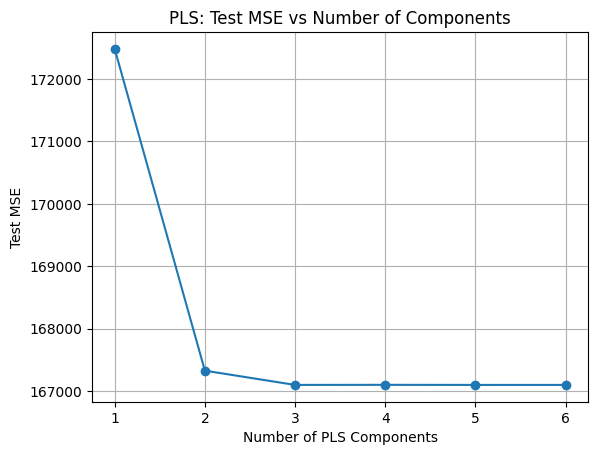

Test MSE comparison:
PCR (2 PCs):   114963.03
PCR (all PCs): 29863.87
Ridge:         29817.99
PLS (optimal components): 167096.24


In [34]:
## Implementation of Partial Least Squares (PLS) following ISL Section 6.3

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# PLS implementation from scratch using the ISL style algorithm
class PLS:
    def __init__(self, n_components):
        self.n_components = n_components
        self.coef_ = None
        
    def fit(self, X, y):
        n_samples, n_features = X.shape
        M = self.n_components
        
        W = np.zeros((n_features, M))
        P = np.zeros((n_features, M))
        c = np.zeros(M)
        
        X_res = X.copy()
        y_res = y.reshape(-1,1)
        
        for i in range(M):
            # Step 1: compute weight
            w = (X_res.T @ y_res) / (y_res.T @ y_res)
            w /= np.linalg.norm(w)
            
            # Step 2: compute score
            t = X_res @ w
            
            # Step 3: regression coefficient
            c_i = (y_res.T @ t) / (t.T @ t)
            
            # Step 4: loadings
            p = (X_res.T @ t) / (t.T @ t)
            
            # Step 5: deflation
            X_res -= t @ p.T
            y_res -= t * c_i
            
            W[:,i] = w.flatten()
            P[:,i] = p.flatten()
            c[i] = c_i.flatten()
        
        # Regression coefficients
        self.coef_ = W @ np.linalg.pinv(P.T @ W) @ c.reshape(-1,1)
        return self
    
    def predict(self, X, y_mean=0):
        return X @ self.coef_ + y_mean

    
    
# Example usage with the Credit dataset
df = pd.read_csv("data/Credit.csv")
X = df[["Income", "Limit", "Rating", "Cards", "Age", "Education"]].values
y = df["Balance"].values
# Standardize predictors 
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_stdized = (X - X_mean) / X_std
# Center response
y_mean = y.mean()
y_centered = y - y_mean
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_stdized, y_centered, test_size=0.2, random_state=42
)

# Fit PLS for 1 to max_components and record test MSE
test_mse_pls = []
max_components = X_train.shape[1]

for n_components in range(1, max_components + 1):
    pls = PLS(n_components=n_components)
    pls.fit(X_train, y_train)
    y_train_centered = y_train
    pls.fit(X_train, y_train_centered)
    # Fit PLS with centered y
    pls.fit(X_train, y_train)  # y_train is already centered
    y_pred = pls.predict(X_test)  # no need to add y_mean
    test_mse = np.mean((y_test - y_pred) ** 2)  # y_test is also centered
    test_mse_pls.append(test_mse)

# Plot
plt.figure()
plt.plot(range(1, max_components + 1), test_mse_pls, marker='o')
plt.xlabel('Number of PLS Components')
plt.ylabel('Test MSE')
plt.title('PLS: Test MSE vs Number of Components')
plt.grid(True)
plt.show()

# Compare with PCR and Ridge (from previous code)
print("Test MSE comparison:")
print(f"PCR (2 PCs):   {mse_pcr_2:.2f}")
print(f"PCR (all PCs): {mse_pcr_all:.2f}")
print(f"Ridge:         {mse_ridge:.2f}")
print(f"PLS (optimal components): {min(test_mse_pls):.2f}")
# ------------------------------------------------------------


C:\Users\Johannes\AppData\Local\Temp\ipykernel_19548\3566423723.py:53: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  c[i] = c_i.flatten()


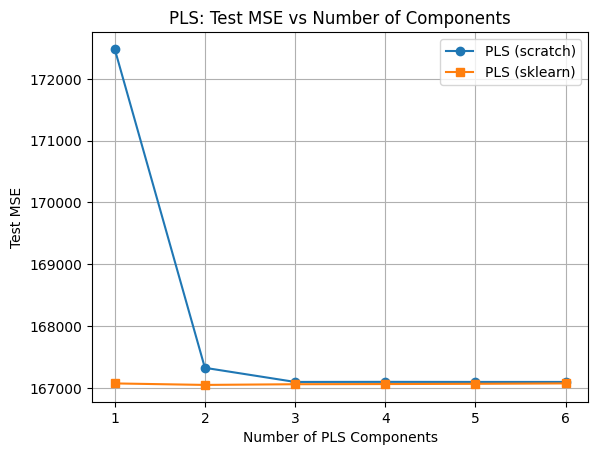

Test MSE comparison
PCR (2 PCs):          114963.03
PCR (all PCs):        29863.87
Ridge:               29817.99
PLS (scratch, best): 167096.24
PLS (sklearn, best): 167047.96


In [39]:
# ============================================================
# PLS from scratch+ sklearn comparison
# ISL Section 6.3 compliant
# Drop-in comparison cell
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.cross_decomposition import PLSRegression

# ------------------------------------------------------------
# Stable PLS implementation (NIPALS, single-response, ISL-style)
# ------------------------------------------------------------
class PLS:
    def __init__(self, n_components):
        self.n_components = n_components
        self.coef_ = None
        
    def fit(self, X, y):
        n_samples, n_features = X.shape
        M = self.n_components
        
        W = np.zeros((n_features, M))
        P = np.zeros((n_features, M))
        c = np.zeros(M)
        
        X_res = X.copy()
        y_res = y.reshape(-1,1)
        
        for i in range(M):
            # Step 1: compute weight
            w = (X_res.T @ y_res) / (y_res.T @ y_res)
            w /= np.linalg.norm(w)
            
            # Step 2: compute score
            t = X_res @ w
            
            # Step 3: regression coefficient
            c_i = (y_res.T @ t) / (t.T @ t)
            
            # Step 4: loadings
            p = (X_res.T @ t) / (t.T @ t)
            
            # Step 5: deflation
            X_res -= t @ p.T
            y_res -= t * c_i
            
            W[:,i] = w.flatten()
            P[:,i] = p.flatten()
            c[i] = c_i.flatten()
        
        # Regression coefficients
        self.coef_ = W @ np.linalg.pinv(P.T @ W) @ c.reshape(-1,1)
        return self
    
    def predict(self, X, y_mean=0):
        return X @ self.coef_ + y_mean
# ------------------------------------------------------------
# Data (same as PCR cell)
# ------------------------------------------------------------
df = pd.read_csv("data/Credit.csv")

# Example usage with the Credit dataset
df = pd.read_csv("data/Credit.csv")
X = df[["Income", "Limit", "Rating", "Cards", "Age", "Education"]].values
y = df["Balance"].values


# Standardize predictors 
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_stdized = (X - X_mean) / X_std
# Center response
y_mean = y.mean()
y_centered = y - y_mean
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_stdized, y_centered, test_size=0.2, random_state=42
)
# Fit PLS for 1 to max_components and record test MSE
mse_pls_scratch = []
max_components = X_train.shape[1]

for n_components in range(1, max_components + 1):
    pls = PLS(n_components=n_components)
    pls.fit(X_train, y_train)
    y_train_centered = y_train
    pls.fit(X_train, y_train_centered)
    # Fit PLS with centered y
    pls.fit(X_train, y_train)  # y_train is already centered
    y_pred = pls.predict(X_test)  # no need to add y_mean
    test_mse = np.mean((y_test - y_pred) ** 2)  # y_test is also centered
    mse_pls_scratch.append(test_mse)

# ------------------------------------------------------------
# sklearn PLSRegression (same preprocessing!)
# ------------------------------------------------------------
mse_pls_sklearn = []

for M in range(1, max_M + 1):
    pls = PLSRegression(n_components=M, scale=False)
    pls.fit(X_train_std, y_train)
    y_pred = pls.predict(X_test_std).ravel()
    mse_pls_sklearn.append(np.mean((y_test - y_pred)**2))

# ------------------------------------------------------------
# Plots
# ------------------------------------------------------------
plt.figure()
plt.plot(range(1, max_M + 1), mse_pls_scratch, marker="o", label="PLS (scratch)")
plt.plot(range(1, max_M + 1), mse_pls_sklearn, marker="s", label="PLS (sklearn)")
plt.xlabel("Number of PLS Components")
plt.ylabel("Test MSE")
plt.title("PLS: Test MSE vs Number of Components")
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# Comparison summary (same scale as PCR / Ridge)
# ------------------------------------------------------------
print("Test MSE comparison")
print(f"PCR (2 PCs):          {mse_pcr_2:.2f}")
print(f"PCR (all PCs):        {mse_pcr_all:.2f}")
print(f"Ridge:               {mse_ridge:.2f}")
print(f"PLS (scratch, best): {min(mse_pls_scratch):.2f}")
print(f"PLS (sklearn, best): {min(mse_pls_sklearn):.2f}")
